In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [8]:
df = pd.read_excel("data/datos_limpios.xlsx")
df

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
0,JKLXIQ,51,56857,102886,718,338,3,6.18,24,0.55,...,0,0,580.00,1,0,0,0,1,0,0
1,4UO7DJ,46,45840,30473,689,291,1,14.28,36,0.34,...,0,0,431.25,1,0,0,0,1,0,0
2,MO3OJW,36,48156,188824,675,161,2,13.35,36,0.55,...,0,0,760.00,0,0,1,0,0,1,0
3,I14TTP,42,41472,40000,582,312,1,11.83,12,0.44,...,1,0,385.66,0,1,0,0,0,1,0
4,8FUIBH,60,70202,40743,652,489,2,9.27,48,0.25,...,1,0,535.14,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76505,SXTHNM,24,17942,40000,823,35,2,12.52,36,0.55,...,0,1,540.62,0,0,1,0,1,0,0
76506,0U329X,54,35399,14989,709,445,1,5.93,48,0.47,...,0,1,164.30,0,0,1,0,0,0,1
76507,MY63P5,28,17390,5000,744,92,3,16.12,12,0.10,...,0,0,26.80,0,0,1,0,1,0,0
76508,EPB8QX,64,40369,40000,680,447,2,7.75,12,0.19,...,1,1,207.42,1,0,0,0,0,1,0


In [9]:
df.columns.unique()

Index(['ID', 'Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion',
       'Ratio_Deuda_Ingresos', 'Estudios', 'Posesion_Hipoteca',
       'Personas_Cargo', 'Fiador', 'Impago', 'Prima', 'Estado_Civil_Casado',
       'Estado_Civil_Divorciado', 'Estado_Civil_Soltero',
       'Tipo_Jornada_Laboral_Autónomo', 'Tipo_Jornada_Laboral_Desempleado',
       'Tipo_Jornada_Laboral_Jornada completa',
       'Tipo_Jornada_Laboral_Tiempo parcial'],
      dtype='str')

CREACION DEL MODELO INICIAL

In [10]:
from sklearn.model_selection import train_test_split

X = df[['Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion',
       'Ratio_Deuda_Ingresos', 'Estudios', 'Posesion_Hipoteca',
       'Personas_Cargo', 'Fiador', 'Impago', 'Estado_Civil_Casado',
       'Estado_Civil_Divorciado', 'Estado_Civil_Soltero',
       'Tipo_Jornada_Laboral_Autónomo', 'Tipo_Jornada_Laboral_Desempleado',
       'Tipo_Jornada_Laboral_Jornada completa',
       'Tipo_Jornada_Laboral_Tiempo parcial']] 
y = df[["Prima"]]

X_train, X_test, y_train, y_test = train_test_split(X, y,train_size = 0.8,random_state = 42,shuffle = True)

In [11]:
# 1. Instanciamos el escalador
escalador = StandardScaler()

# 2. "Entrenamos" el escalador SOLO con los datos de Train y los transformamos
# Usamos un DataFrame de Pandas para no perder los nombres de las columnas
X_train_scaled = pd.DataFrame(
    escalador.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

# 3. Transformamos los datos de Test usando la misma regla que aprendió del Train
X_test_scaled = pd.DataFrame(
    escalador.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [12]:
# Creamos la instancia del modelo
modelo_sklearn = LinearRegression()

# Entrenamos el modelo asegurándonos de convertir y_train a un formato unidimensional con squeeze()
modelo_sklearn.fit(X=X_train_scaled, y=y_train.squeeze())

print("Intercepto (Productividad base estandarizada):", round(modelo_sklearn.intercept_, 2))
print("Impacto de cada variable (en desviaciones estandar):")

# Iteramos juntando los nombres originales con los coeficientes generados
for nombre, coeficiente in zip(X.columns, modelo_sklearn.coef_):
    print(f" - {nombre}: {round(coeficiente, 2)}")

print(f"Coeficiente de determinación R^2:", round(modelo_sklearn.score(X_test_scaled, y_test), 2))

Intercepto (Productividad base estandarizada): 384.31
Impacto de cada variable (en desviaciones estandar):
 - Edad: 9.88
 - Ingresos: 21.53
 - Monto_Inicial: 95.88
 - Scoring_Crediticio: -58.6
 - Meses_Empleo: -2.34
 - Num_Creditos: -0.02
 - Ratio_Interes: 36.28
 - Duracion: 82.83
 - Ratio_Deuda_Ingresos: 124.48
 - Estudios: 9.11
 - Posesion_Hipoteca: 0.36
 - Personas_Cargo: 0.62
 - Fiador: 0.43
 - Impago: 0.26
 - Estado_Civil_Casado: 1.97
 - Estado_Civil_Divorciado: 0.13
 - Estado_Civil_Soltero: -2.26
 - Tipo_Jornada_Laboral_Autónomo: 0.33
 - Tipo_Jornada_Laboral_Desempleado: -0.69
 - Tipo_Jornada_Laboral_Jornada completa: 0.53
 - Tipo_Jornada_Laboral_Tiempo parcial: -0.43
Coeficiente de determinación R^2: 0.68


In [13]:
# 1. Hacemos las predicciones sobre el X_test escalado
predicciones = modelo_sklearn.predict(X=X_test_scaled)

# 2. Calculamos los errores
mse = mean_squared_error(y_true=y_test, y_pred=predicciones)
rmse = root_mean_squared_error(y_true=y_test, y_pred=predicciones)
mae = mean_absolute_error(y_true=y_test, y_pred=predicciones)

print("\n--- Resultados de la Evaluación ---")
print("RMSE (Raíz del Error Cuadrático Medio):", round(rmse, 2))
print("MAE (Error Absoluto Medio):", round(mae, 2))



--- Resultados de la Evaluación ---
RMSE (Raíz del Error Cuadrático Medio): 151.07
MAE (Error Absoluto Medio): 119.47


In [14]:
# 1. Añadimos la constante a los datos escalados de entrenamiento
X_train_sm = sm.add_constant(X_train_scaled, prepend=True)

# 2. Creamos y entrenamos el modelo estadístico
modelo_sm = sm.OLS(endog=y_train, exog=X_train_sm)
resultados_sm = modelo_sm.fit()

# 3. Imprimimos el resumen
print(resultados_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Prima   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     6770.
Date:               lu., 05 oct. 2026   Prob (F-statistic):               0.00
Time:                        15:44:58   Log-Likelihood:            -3.9425e+05
No. Observations:               61208   AIC:                         7.885e+05
Df Residuals:                   61188   BIC:                         7.887e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

C:\Users\asanz\AppData\Local\Temp\ipykernel_33896\3845584576.py:6: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resultados_sm = modelo_sm.fit()


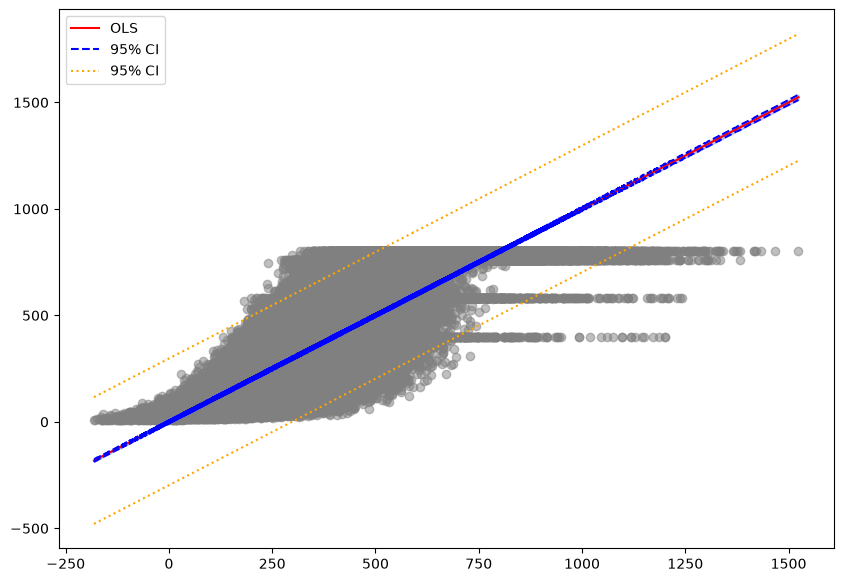

In [15]:
# 1. Extraemos predicciones y sus bandas de confianza
predicciones_sm = resultados_sm.get_prediction(exog=X_train_sm).summary_frame(alpha=0.05)

# 2. Añadimos el valor real y ordenamos para el dibujo
predicciones_sm["y_real"] = y_train.values
predicciones_sm = predicciones_sm.sort_values("mean")

# 3. Creamos el lienzo
fig, ax = plt.subplots(figsize=(10, 7))

# 4. Puntos de Dispersión
ax.scatter(predicciones_sm["mean"], predicciones_sm["y_real"], marker="o", color="gray", alpha=0.5)

# 5. Línea ideal del modelo
ax.plot(predicciones_sm["mean"], predicciones_sm["mean"], linestyle="-", color="red", label="OLS")

ax.plot(predicciones_sm["mean"], predicciones_sm["mean_ci_lower"], linestyle="--", color="blue", label="95% CI")
ax.plot(predicciones_sm["mean"], predicciones_sm["mean_ci_upper"], linestyle="--", color="blue")
ax.fill_between(predicciones_sm["mean"], predicciones_sm["mean_ci_lower"], predicciones_sm["mean_ci_upper"], alpha=0.2, color="blue")

ax.plot(predicciones_sm["mean"], predicciones_sm["obs_ci_lower"], linestyle=":", color="orange", label="95% CI")
ax.plot(predicciones_sm["mean"], predicciones_sm["obs_ci_upper"], linestyle=":", color="orange")

ax.legend()

plt.show()

CREACION DEL MODELO AJUSTADO, POLINOMICO

In [22]:
# 2. Seleccionar variables (omitimos las redundantes y no significativas del análisis previo)
variables_predictoras = [
    'Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
    'Ratio_Interes', 'Duracion', 'Ratio_Deuda_Ingresos', 
    'Estudios', 'Estado_Civil_Casado'
]

X = df[variables_predictoras]
y = df['Prima']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size = 0.8,random_state = 42,shuffle = True)

In [24]:
# Generamos la clase polinómica (Grado 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# Transformamos los datos de entrenamiento y prueba
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Mantenemos los nombres de las variables generadas
nombres_poly = poly_features.get_feature_names_out(variables_predictoras)
X_train_poly = pd.DataFrame(X_train_poly, columns=nombres_poly, index=X_train.index)
X_test_poly = pd.DataFrame(X_test_poly, columns=nombres_poly, index=X_test.index)

# Estandarizamos para estabilizar el cálculo
escalador = StandardScaler()
X_train_scaled = pd.DataFrame(escalador.fit_transform(X_train_poly), columns=nombres_poly, index=X_train.index)
X_test_scaled = pd.DataFrame(escalador.transform(X_test_poly), columns=nombres_poly, index=X_test.index)

In [25]:
# Añadimos la constante
X_train_sm = sm.add_constant(X_train_scaled, prepend=True)
X_test_sm = sm.add_constant(X_test_scaled, prepend=True)

# Creamos y entrenamos el modelo estadístico
modelo_sm = sm.OLS(endog=y_train, exog=X_train_sm)
resultados_sm = modelo_sm.fit()

# Imprimimos el resumen
print(resultados_sm.summary())

# Intervalos de confianza al 95%
intervalos_ci = resultados_sm.conf_int(alpha=0.05)
intervalos_ci.columns = ['2.5%', '97.5%']
print("\nIntervalos de Confianza:\n", intervalos_ci.head())

                            OLS Regression Results                            
Dep. Variable:                  Prima   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     7566.
Date:               lu., 05 oct. 2026   Prob (F-statistic):               0.00
Time:                        15:47:16   Log-Likelihood:            -3.6700e+05
No. Observations:               61208   AIC:                         7.341e+05
Df Residuals:                   61154   BIC:                         7.346e+05
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

C:\Users\asanz\AppData\Local\Temp\ipykernel_33896\3264669914.py:7: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resultados_sm = modelo_sm.fit()


RMSE Promedio Estimado (CV-5): 97.33


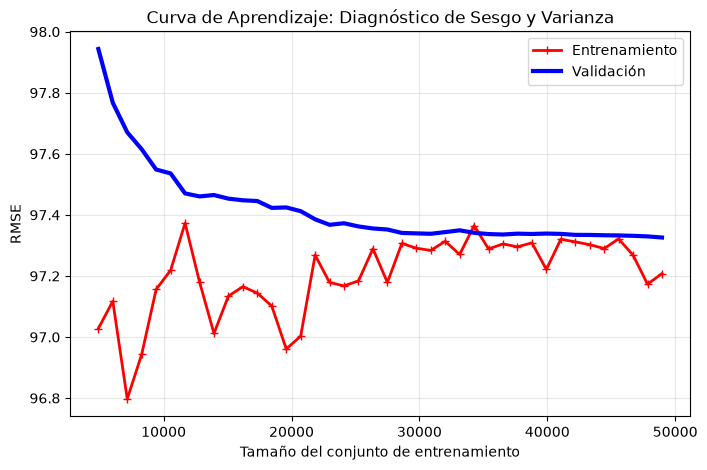

In [31]:
# Validación Cruzada
modelo_cv = LinearRegression()
mse_scores = cross_val_score(modelo_cv, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-mse_scores.mean())
print(f"RMSE Promedio Estimado (CV-5): {rmse_cv:.2f}")

# Generamos la curva de aprendizaje
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X_train_scaled, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 40),
    cv=5, scoring="neg_root_mean_squared_error"
)

# Promediamos y corregimos el signo negativo
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

# Gráfico de Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Entrenamiento")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="Validación")
plt.legend()
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("RMSE")
plt.title("Curva de Aprendizaje: Diagnóstico de Sesgo y Varianza")
plt.grid(True, alpha=0.3)
plt.show()


RMSE de Test: 98.43
MAE de Test: 75.55

Test D'Agostino's K-squared: p-value = 0.0000


C:\Users\asanz\AppData\Local\Temp\ipykernel_33896\116684420.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2, color='yellow')


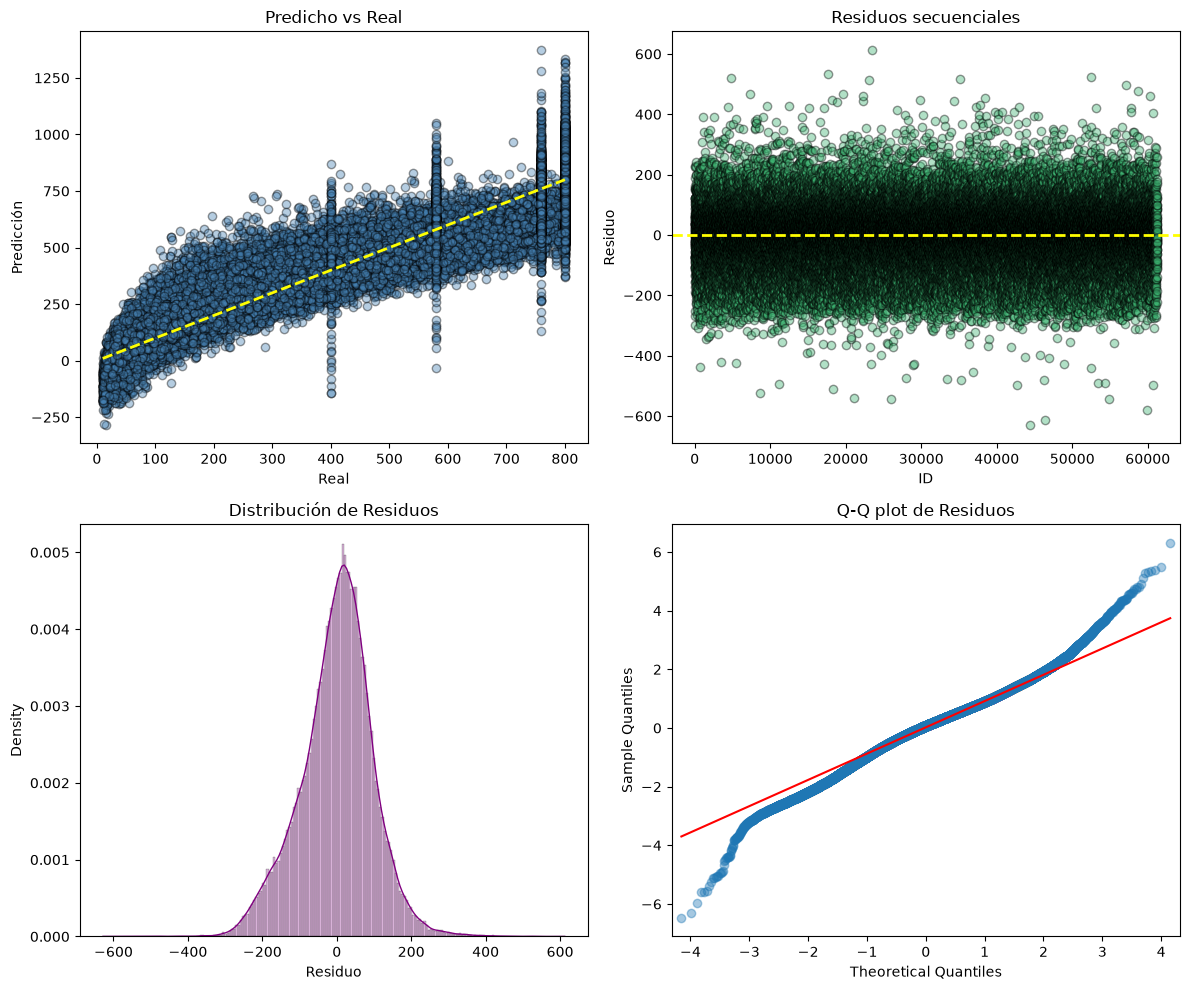

In [30]:
# Generamos predicciones en Test
predicciones_test = resultados_sm.predict(X_test_sm)

# Errores globales
rmse_final = np.sqrt(mean_squared_error(y_test, predicciones_test))
mae_final = mean_absolute_error(y_test, predicciones_test)
print(f"\nRMSE de Test: {rmse_final:.2f}")
print(f"MAE de Test: {mae_final:.2f}")

# Diagnóstico de residuos en Entrenamiento
prediccion_train = resultados_sm.predict(X_train_sm)
residuos_train = prediccion_train - y_train.squeeze()

# Test formales de Normalidad
shapiro_test = stats.shapiro(residuos_train[:5000]) # Se limita por rendimiento
k2, p_value = stats.normaltest(residuos_train)
print(f"\nTest D'Agostino's K-squared: p-value = {p_value:.4f}")

# --- Construcción del Gráfico de Diagnóstico Múltiple ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# 1. Valor predicho vs Valor real
axes[0, 0].scatter(y_train, prediccion_train, edgecolors=(0, 0, 0), alpha=0.4, color='steelblue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2, color='yellow')
axes[0, 0].set_title('Predicho vs Real')
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Predicción')

# 2. Residuos en el tiempo / índice (Detectar autocorrelación)
axes[0, 1].scatter(range(len(y_train)), residuos_train, edgecolors=(0, 0, 0), alpha=0.4, color='mediumseagreen')
axes[0, 1].axhline(y=0, linestyle='--', color='yellow', lw=2)
axes[0, 1].set_title('Residuos secuenciales')
axes[0, 1].set_xlabel('ID')
axes[0, 1].set_ylabel('Residuo')

# 3. Histograma de Residuos (Normalidad)
sns.histplot(data=residuos_train, stat="density", kde=True, line_kws={'linewidth': 1}, alpha=0.3, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribución de Residuos')
axes[1, 0].set_xlabel("Residuo")

# 4. Q-Q Plot (Distribución teórica Normal vs Real)
sm.qqplot(residuos_train, fit=True, line='q', ax=axes[1, 1], alpha=0.4, lw=2)
axes[1, 1].set_title('Q-Q plot de Residuos')

fig.tight_layout()
plt.show()